In [3]:
import numpy as np
import pandas as pd
import country_converter as coco
import matplotlib.pyplot as plt

# Checking the structure of the Data

In [5]:
df = pd.read_csv("../Data/Raw/Gini_Index.csv")
print(df.head(10))

       country  year  gini_disp  gini_disp_se  gini_mkt  gini_mkt_se  abs_red  \
0  Afghanistan  2007       31.4          2.48      32.7         2.72      NaN   
1  Afghanistan  2008       31.4          2.40      32.8         2.65      NaN   
2  Afghanistan  2009       31.5          2.45      32.9         2.72      NaN   
3  Afghanistan  2010       31.6          2.47      33.0         2.76      NaN   
4  Afghanistan  2011       31.7          2.49      33.1         2.75      NaN   
5  Afghanistan  2012       31.8          2.49      33.2         2.76      NaN   
6  Afghanistan  2013       31.8          2.64      33.2         2.90      NaN   
7  Afghanistan  2014       31.9          2.76      33.2         3.03      NaN   
8  Afghanistan  2015       31.9          2.89      33.2         3.14      NaN   
9  Afghanistan  2016       31.9          3.01      33.3         3.24      NaN   

   abs_red_se  rel_red  rel_red_se  
0         NaN      NaN         NaN  
1         NaN      NaN         NaN

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6628 entries, 0 to 6627
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       6628 non-null   object 
 1   year          6628 non-null   int64  
 2   gini_disp     6628 non-null   float64
 3   gini_disp_se  6628 non-null   float64
 4   gini_mkt      6628 non-null   float64
 5   gini_mkt_se   6628 non-null   float64
 6   abs_red       2756 non-null   float64
 7   abs_red_se    2756 non-null   float64
 8   rel_red       2756 non-null   float64
 9   rel_red_se    2756 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 517.9+ KB


Data has the 9 columns and description for each column is per Data Documentation in DATA_NOTES.md. Last 4 columns has more than 60% null values.

In [4]:
df.country.nunique()

199

Data has 199 unique countries of data

In [6]:
df['country'].value_counts()

country
Brazil                      65
Costa Rica                  65
United States               65
Argentina                   64
United Kingdom              64
                            ..
Brunei                       1
Bahrain                      1
Marshall Islands             1
Somalia                      1
Turks and Caicos Islands     1
Name: count, Length: 199, dtype: int64

In the data each country has different data coverage.

# prioritizing highest data coverage within each region

## maximize coverage while keeping the regional structure meaningful.

In [6]:
# Master country list (114 from our full regional breakdown)
# Comment out / remove entries here to trim down to your target 114
COUNTRIES = [
    # North America
    "United States", "Canada", "Puerto Rico",
    # Western Europe
    "United Kingdom", "Germany", "France", "Ireland", "Belgium",
    "Netherlands", "Switzerland", "Luxembourg", "Austria",
    # Nordic
    "Sweden", "Norway", "Finland", "Denmark",
    # Southern Europe
    "Italy", "Portugal", "Spain", "Greece", "Cyprus",
    # Eastern Europe & Former Soviet
    "Hungary", "Poland", "Ukraine", "Uzbekistan", "Georgia", "Kyrgyzstan",
    "Slovenia", "Tajikistan", "Kazakhstan", "Moldova", "Estonia", "Belarus",
    "Armenia", "Croatia", "Lithuania", "Slovakia", "Czech Republic",
    "Latvia", "Russia", "Bulgaria", "Romania",
    # East Asia
    "Japan", "Taiwan", "Korea", "Hong Kong", "China",
    # South Asia
    "Pakistan", "India", "Bangladesh", "Sri Lanka", "Nepal",
    # Southeast Asia
    "Philippines", "Thailand", "Indonesia", "Malaysia", "Singapore",
    "Vietnam", "Laos",
    # Middle East & North Africa
    "Iran", "Israel", "Egypt", "Turkey", "Jordan", "Tunisia", "Morocco", "Qatar",
    # Sub-Saharan Africa
    "Madagascar", "Malawi", "Tanzania", "Sierra Leone", "South Africa",
    "Zambia", "Sudan", "Kenya", "Nigeria", "Rwanda", "Côte d'Ivoire",
    "Mauritania", "Lesotho", "Eswatini", "Guinea-Bissau", "Mauritius",
    "Mali", "Uganda", "Senegal", "Botswana", "Central African Republic",
    "Niger", "Ghana",
    # Latin America & Caribbean
    "Brazil", "Costa Rica", "Argentina", "Mexico", "Venezuela", "Chile",
    "Panama", "Colombia", "Peru", "Uruguay", "Guatemala",
    "Dominican Republic", "Barbados", "Honduras", "El Salvador", "Paraguay",
    "Trinidad and Tobago", "Jamaica", "Bolivia", "Ecuador",
    # Oceania
    "New Zealand", "Australia", "Fiji", "Tonga",
]

print(f"Country list length: {len(COUNTRIES)}")  # sanity check before filtering
assert len(COUNTRIES) == len(set(COUNTRIES)), "Duplicate country names found in list!"

# Apply filter to each dataset
df_filtered = df[df['country'].isin(COUNTRIES)].copy()

print(f"Rows before filter: {len(df)}")
print(f"Rows after filter:  {len(df_filtered)}")
print(f"Unique countries retained: {df_filtered['country'].nunique()} / {len(COUNTRIES)}")

# Flag any countries in your list that had ZERO matching rows in this dataset
# (catches spelling mismatches before they silently drop a country)
missing = set(COUNTRIES) - set(df_filtered['country'].unique())
if missing:
    print(f"⚠️ No data found for: {missing}")

Country list length: 114
Rows before filter: 6628
Rows after filter:  5155
Unique countries retained: 114 / 114


Only keeping the countries with high coverage of data while keeping the regional structure meaningful.

## Mapping each country with its meaningful region

In [7]:
# Country -> Region mapping (114 countries, 12 regions)
REGION_MAP = {
    # North America
    "United States": "North America", "Canada": "North America",
    "Puerto Rico": "North America",

    # Western Europe
    "United Kingdom": "Western Europe", "Germany": "Western Europe",
    "France": "Western Europe", "Ireland": "Western Europe",
    "Belgium": "Western Europe", "Netherlands": "Western Europe",
    "Switzerland": "Western Europe", "Luxembourg": "Western Europe",
    "Austria": "Western Europe",

    # Nordic
    "Sweden": "Nordic", "Norway": "Nordic",
    "Finland": "Nordic", "Denmark": "Nordic",

    # Southern Europe
    "Italy": "Southern Europe", "Portugal": "Southern Europe",
    "Spain": "Southern Europe", "Greece": "Southern Europe",
    "Cyprus": "Southern Europe",

    # Eastern Europe & Former Soviet
    "Hungary": "Eastern Europe & FSU", "Poland": "Eastern Europe & FSU",
    "Ukraine": "Eastern Europe & FSU", "Uzbekistan": "Eastern Europe & FSU",
    "Georgia": "Eastern Europe & FSU", "Kyrgyzstan": "Eastern Europe & FSU",
    "Slovenia": "Eastern Europe & FSU", "Tajikistan": "Eastern Europe & FSU",
    "Kazakhstan": "Eastern Europe & FSU", "Moldova": "Eastern Europe & FSU",
    "Estonia": "Eastern Europe & FSU", "Belarus": "Eastern Europe & FSU",
    "Armenia": "Eastern Europe & FSU", "Croatia": "Eastern Europe & FSU",
    "Lithuania": "Eastern Europe & FSU", "Slovakia": "Eastern Europe & FSU",
    "Czech Republic": "Eastern Europe & FSU", "Latvia": "Eastern Europe & FSU",
    "Russia": "Eastern Europe & FSU", "Bulgaria": "Eastern Europe & FSU",
    "Romania": "Eastern Europe & FSU",

    # East Asia
    "Japan": "East Asia", "Taiwan": "East Asia", "Korea": "East Asia",
    "Hong Kong": "East Asia", "China": "East Asia",

    # South Asia
    "Pakistan": "South Asia", "India": "South Asia",
    "Bangladesh": "South Asia", "Sri Lanka": "South Asia",
    "Nepal": "South Asia",

    # Southeast Asia
    "Philippines": "Southeast Asia", "Thailand": "Southeast Asia",
    "Indonesia": "Southeast Asia", "Malaysia": "Southeast Asia",
    "Singapore": "Southeast Asia", "Vietnam": "Southeast Asia",
    "Laos": "Southeast Asia",

    # Middle East & North Africa
    "Iran": "MENA", "Israel": "MENA", "Egypt": "MENA",
    "Turkey": "MENA", "Jordan": "MENA", "Tunisia": "MENA",
    "Morocco": "MENA", "Qatar": "MENA",

    # Sub-Saharan Africa
    "Madagascar": "Sub-Saharan Africa", "Malawi": "Sub-Saharan Africa",
    "Tanzania": "Sub-Saharan Africa", "Sierra Leone": "Sub-Saharan Africa",
    "South Africa": "Sub-Saharan Africa", "Zambia": "Sub-Saharan Africa",
    "Sudan": "Sub-Saharan Africa", "Kenya": "Sub-Saharan Africa",
    "Nigeria": "Sub-Saharan Africa", "Rwanda": "Sub-Saharan Africa",
    "Côte d'Ivoire": "Sub-Saharan Africa", "Mauritania": "Sub-Saharan Africa",
    "Lesotho": "Sub-Saharan Africa", "Eswatini": "Sub-Saharan Africa",
    "Guinea-Bissau": "Sub-Saharan Africa", "Mauritius": "Sub-Saharan Africa",
    "Mali": "Sub-Saharan Africa", "Uganda": "Sub-Saharan Africa",
    "Senegal": "Sub-Saharan Africa", "Botswana": "Sub-Saharan Africa",
    "Central African Republic": "Sub-Saharan Africa", "Niger": "Sub-Saharan Africa",
    "Ghana": "Sub-Saharan Africa",

    # Latin America & Caribbean
    "Brazil": "Latin America & Caribbean", "Costa Rica": "Latin America & Caribbean",
    "Argentina": "Latin America & Caribbean", "Mexico": "Latin America & Caribbean",
    "Venezuela": "Latin America & Caribbean", "Chile": "Latin America & Caribbean",
    "Panama": "Latin America & Caribbean", "Colombia": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean", "Uruguay": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean", "Dominican Republic": "Latin America & Caribbean",
    "Barbados": "Latin America & Caribbean", "Honduras": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean", "Paraguay": "Latin America & Caribbean",
    "Trinidad and Tobago": "Latin America & Caribbean", "Jamaica": "Latin America & Caribbean",
    "Bolivia": "Latin America & Caribbean", "Ecuador": "Latin America & Caribbean",

    # Oceania
    "New Zealand": "Oceania", "Australia": "Oceania",
    "Fiji": "Oceania", "Tonga": "Oceania",
}

print(f"Total countries mapped: {len(REGION_MAP)}")
print(f"Total regions: {len(set(REGION_MAP.values()))}")

# --- Apply to dataframe ---
df_filtered['region'] = df_filtered['country'].map(REGION_MAP)

# --- Validation: catch unmapped countries before they silently become NaN ---
unmapped = df_filtered.loc[df_filtered['region'].isna(), 'country'].unique()
if len(unmapped) > 0:
    print(f"⚠️ {len(unmapped)} countries in the dataframe have no region assigned:")
    print(sorted(unmapped))
else:
    print("✅ All countries successfully mapped to a region.")

# --- Sanity check: region distribution ---
print("\nCountries per region:")
print(df_filtered.groupby('region').agg({'country': 'nunique'}).sort_values(by = 'country', ascending=False))

Total countries mapped: 114
Total regions: 12
✅ All countries successfully mapped to a region.

Countries per region:
                           country
region                            
Sub-Saharan Africa              23
Eastern Europe & FSU            21
Latin America & Caribbean       20
Western Europe                   9
MENA                             8
Southeast Asia                   7
East Asia                        5
South Asia                       5
Southern Europe                  5
Nordic                           4
Oceania                          4
North America                    3


# Standardizing the country names all across the all data set

In [8]:
cc = coco.CountryConverter()

# Convert your SWIID country names to ISO3
df_filtered['iso3'] = cc.convert(names=df_filtered['country'], to='ISO3', not_found=None)

# Check for anything it couldn't match
unmatched = df_filtered[df_filtered['iso3'].isna()]['country'].unique()
print("Unmatched countries:", unmatched)

Unmatched countries: []


In [9]:
df_filtered.head(5)

,country,year,gini_disp,gini_disp_se,gini_mkt,gini_mkt_se,abs_red,abs_red_se,rel_red,rel_red_se,region,iso3
106,Argentina,1961,36.3,2.65,37.8,3.43,NaN,NaN,NaN,NaN,Latin America & Caribbean,ARG
107,Argentina,1962,36.1,2.53,37.8,3.32,NaN,NaN,NaN,NaN,Latin America & Caribbean,ARG
108,Argentina,1963,36.0,2.39,37.7,3.24,NaN,NaN,NaN,NaN,Latin America & Caribbean,ARG
109,Argentina,1964,35.9,2.34,37.7,3.19,NaN,NaN,NaN,NaN,Latin America & Caribbean,ARG
110,Argentina,1965,35.9,2.26,37.7,3.11,NaN,NaN,NaN,NaN,Latin America & Caribbean,ARG


# Handling missing values in dataset

## Adding manually calculated values for abs_red and rel_red while keeping original values as it is.

In [10]:
# Flag before you touch anything
df_filtered['abs_red_source'] = df_filtered['abs_red'].apply(lambda x: 'survey' if pd.notna(x) else 'derived')

# Fill missing abs_red / rel_red using the arithmetic relationship
df_filtered['abs_red'] = df_filtered['abs_red'].fillna(df_filtered['gini_mkt'] - df_filtered['gini_disp'])
df_filtered['rel_red'] = df_filtered['rel_red'].fillna((df_filtered['gini_mkt'] - df_filtered['gini_disp']) / df_filtered['gini_mkt'])

# Sanity check the split
print(df_filtered['abs_red_source'].value_counts())

abs_red_source
survey     2633
derived    2522
Name: count, dtype: int64


In [11]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5155 entries, 106 to 6602
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         5155 non-null   object 
 1   year            5155 non-null   int64  
 2   gini_disp       5155 non-null   float64
 3   gini_disp_se    5155 non-null   float64
 4   gini_mkt        5155 non-null   float64
 5   gini_mkt_se     5155 non-null   float64
 6   abs_red         5155 non-null   float64
 7   abs_red_se      2633 non-null   float64
 8   rel_red         5155 non-null   float64
 9   rel_red_se      2633 non-null   float64
 10  region          5155 non-null   object 
 11  iso3            5155 non-null   object 
 12  abs_red_source  5155 non-null   object 
dtypes: float64(8), int64(1), object(4)
memory usage: 563.8+ KB


# Checking for inappropriate data points

## Calculating interquartile range for each country and extrcting those with outliers.

In [12]:
# Function to calculate interquartile range and outliers, returning data frame with outliers data points
def iqr_outliers_per_country(df, col):
    results = []
    for country, group in df.groupby('country'):
        series = group[col].dropna()
        if len(series) < 4:  # too few points for a meaningful IQR
            continue
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (series < lower) | (series > upper)
        if mask.any():
            flagged = group.loc[series[mask].index, ['country', 'year', col]]
            results.append(flagged)
    return pd.concat(results) if results else pd.DataFrame()

# Store countries with outliers in columns gini_disp and gini_mkt in two separate variables.
outliers_by_country_disp = iqr_outliers_per_country(df_filtered, 'gini_disp')
outliers_by_country_mkt = iqr_outliers_per_country(df_filtered, 'gini_mkt')
gini_disp_outliers = set(outliers_by_country_disp['country'].unique())
gini_mkt_outliers = set(outliers_by_country_mkt['country'].unique())

## Investigating further to decide inappropriate data points for each flagged countries.

### Ploting plots for countries flagged for 'gini_disp' column

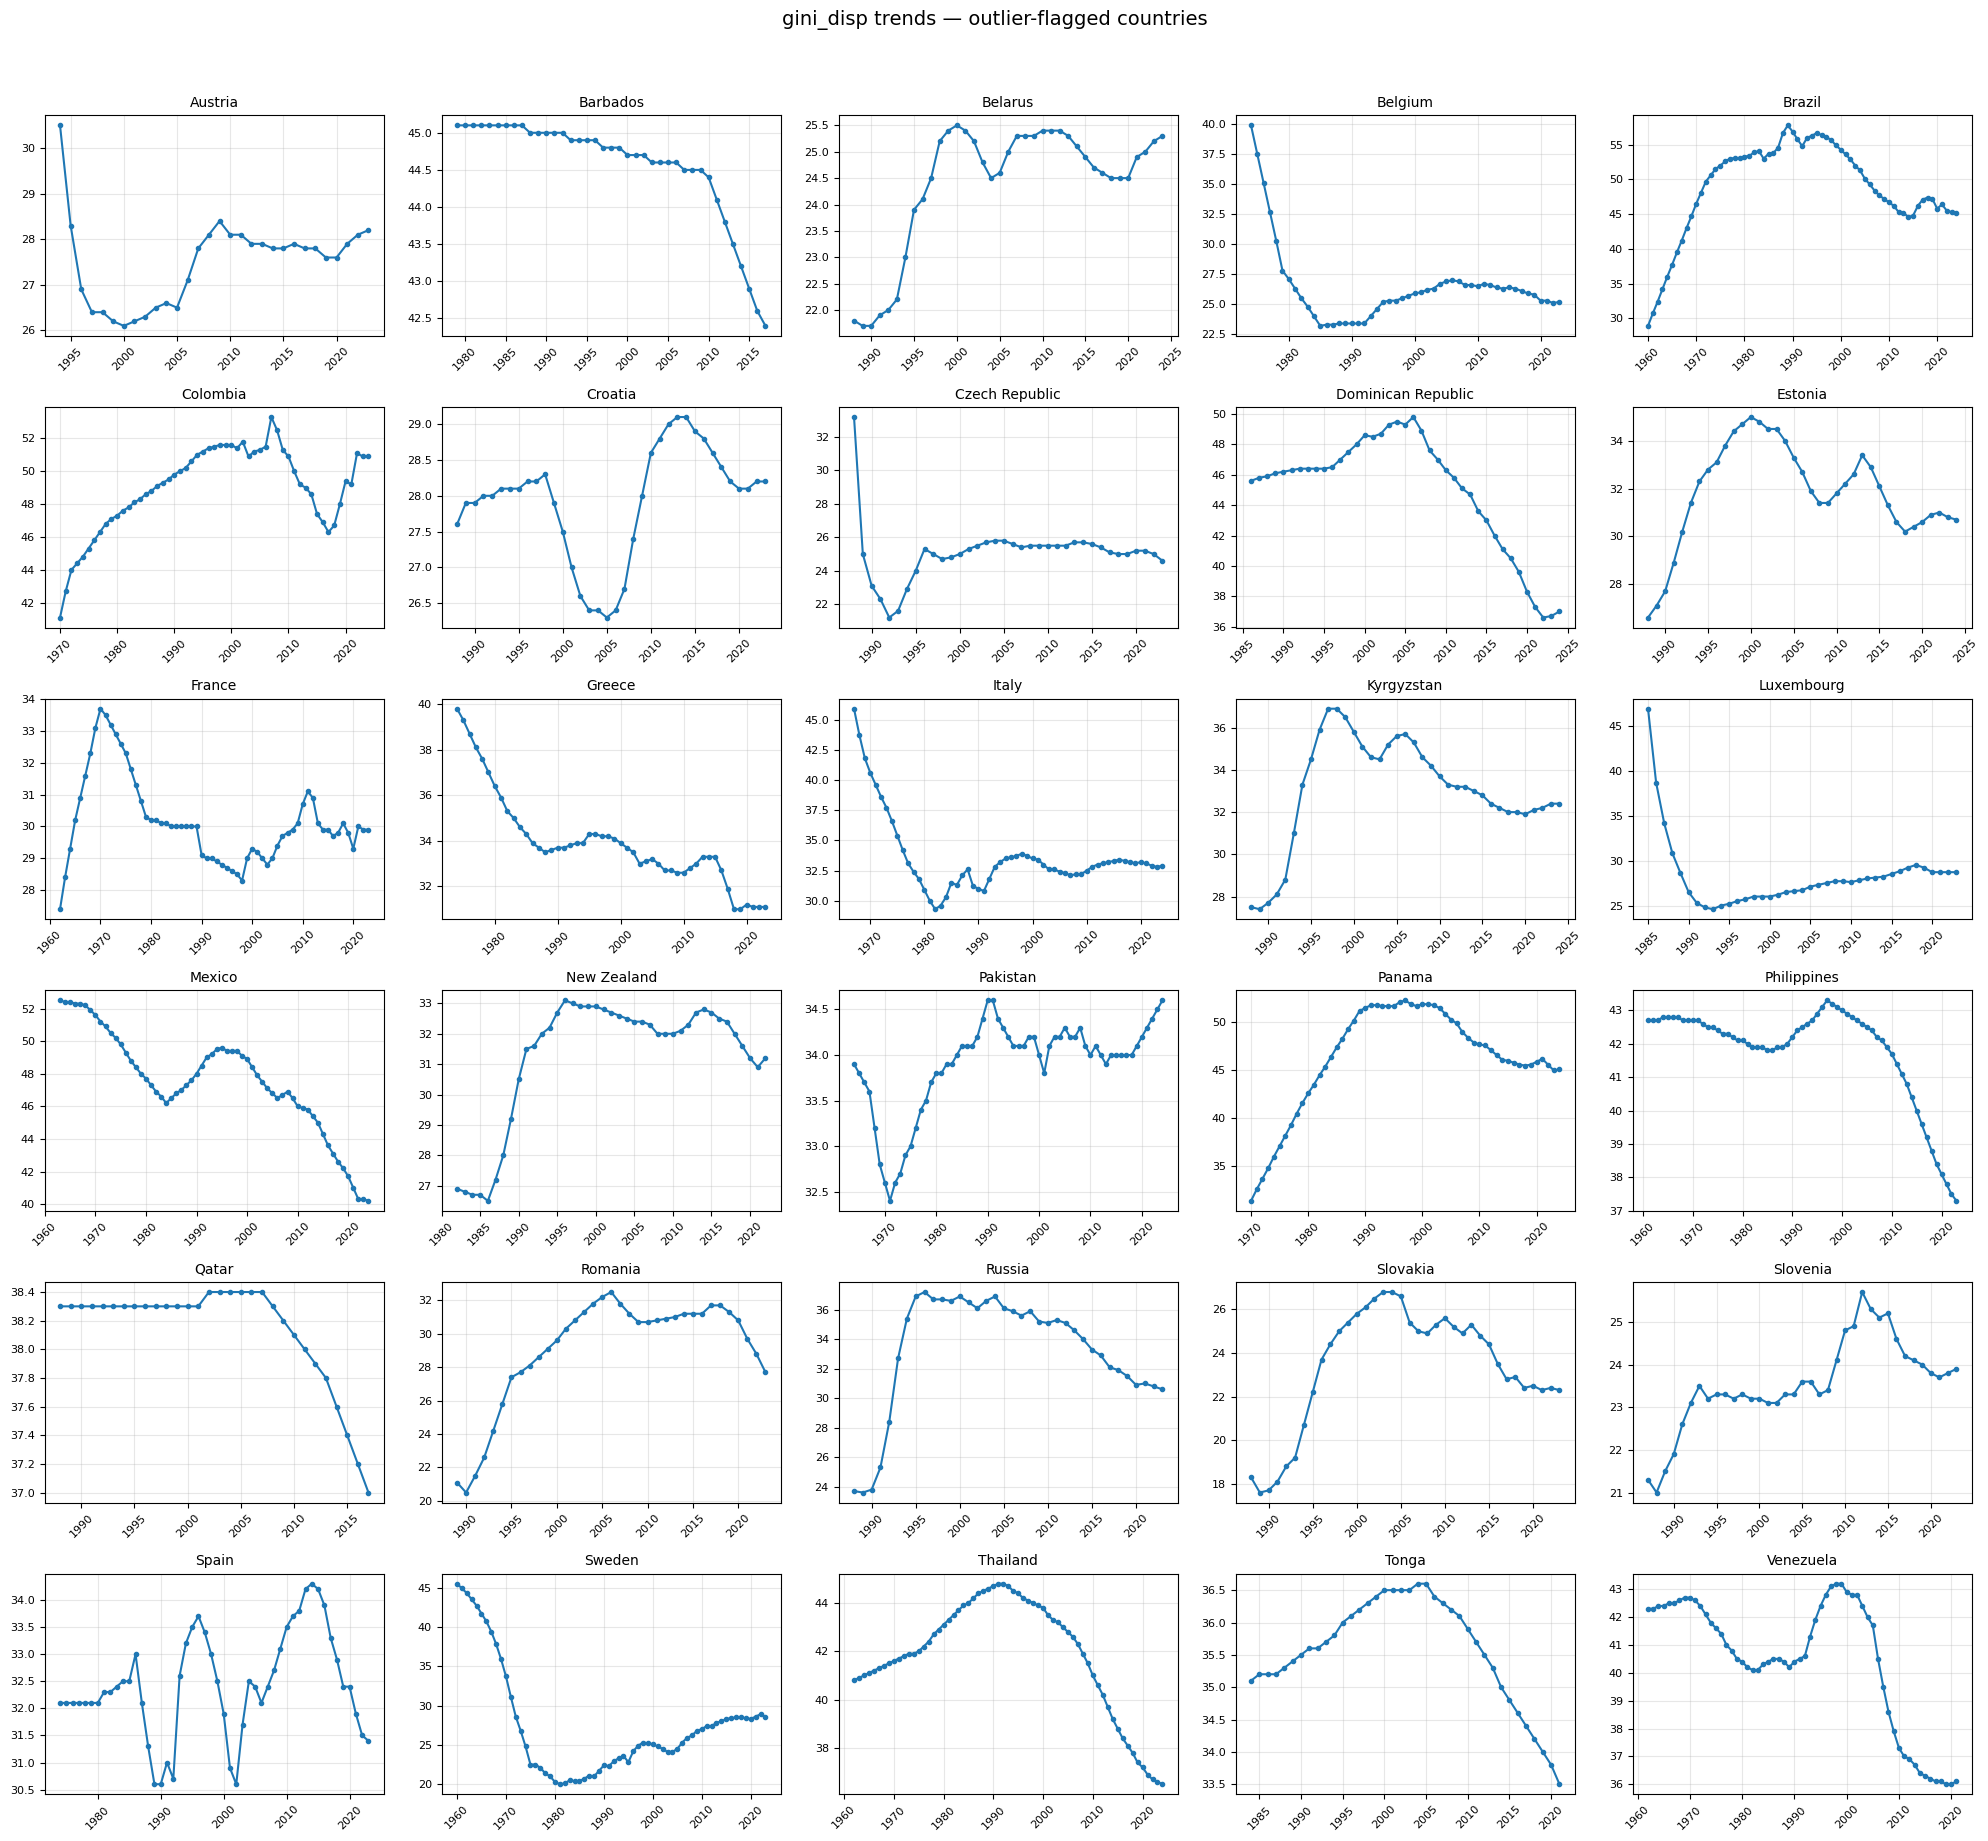

In [13]:
def plot_all_trends(df, countries, col='gini_disp', cols_per_row=4):
    countries = sorted(countries)
    n = len(countries)
    n_rows = int(np.ceil(n / cols_per_row))

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 4, n_rows * 3))
    axes = axes.flatten()  # makes indexing easy regardless of grid shape

    for i, country in enumerate(countries):
        subset = df[df['country'] == country].sort_values('year')
        axes[i].plot(subset['year'], subset[col], marker='o', markersize=3)
        axes[i].set_title(country, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].grid(alpha=0.3)

    # Hide any unused subplot slots (if grid has more cells than countries)
    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{col} trends — outlier-flagged countries', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_trends(df_filtered, gini_disp_outliers, col='gini_disp', cols_per_row=5)

### Ploting plots for countries flagged for 'gini_mkt' column

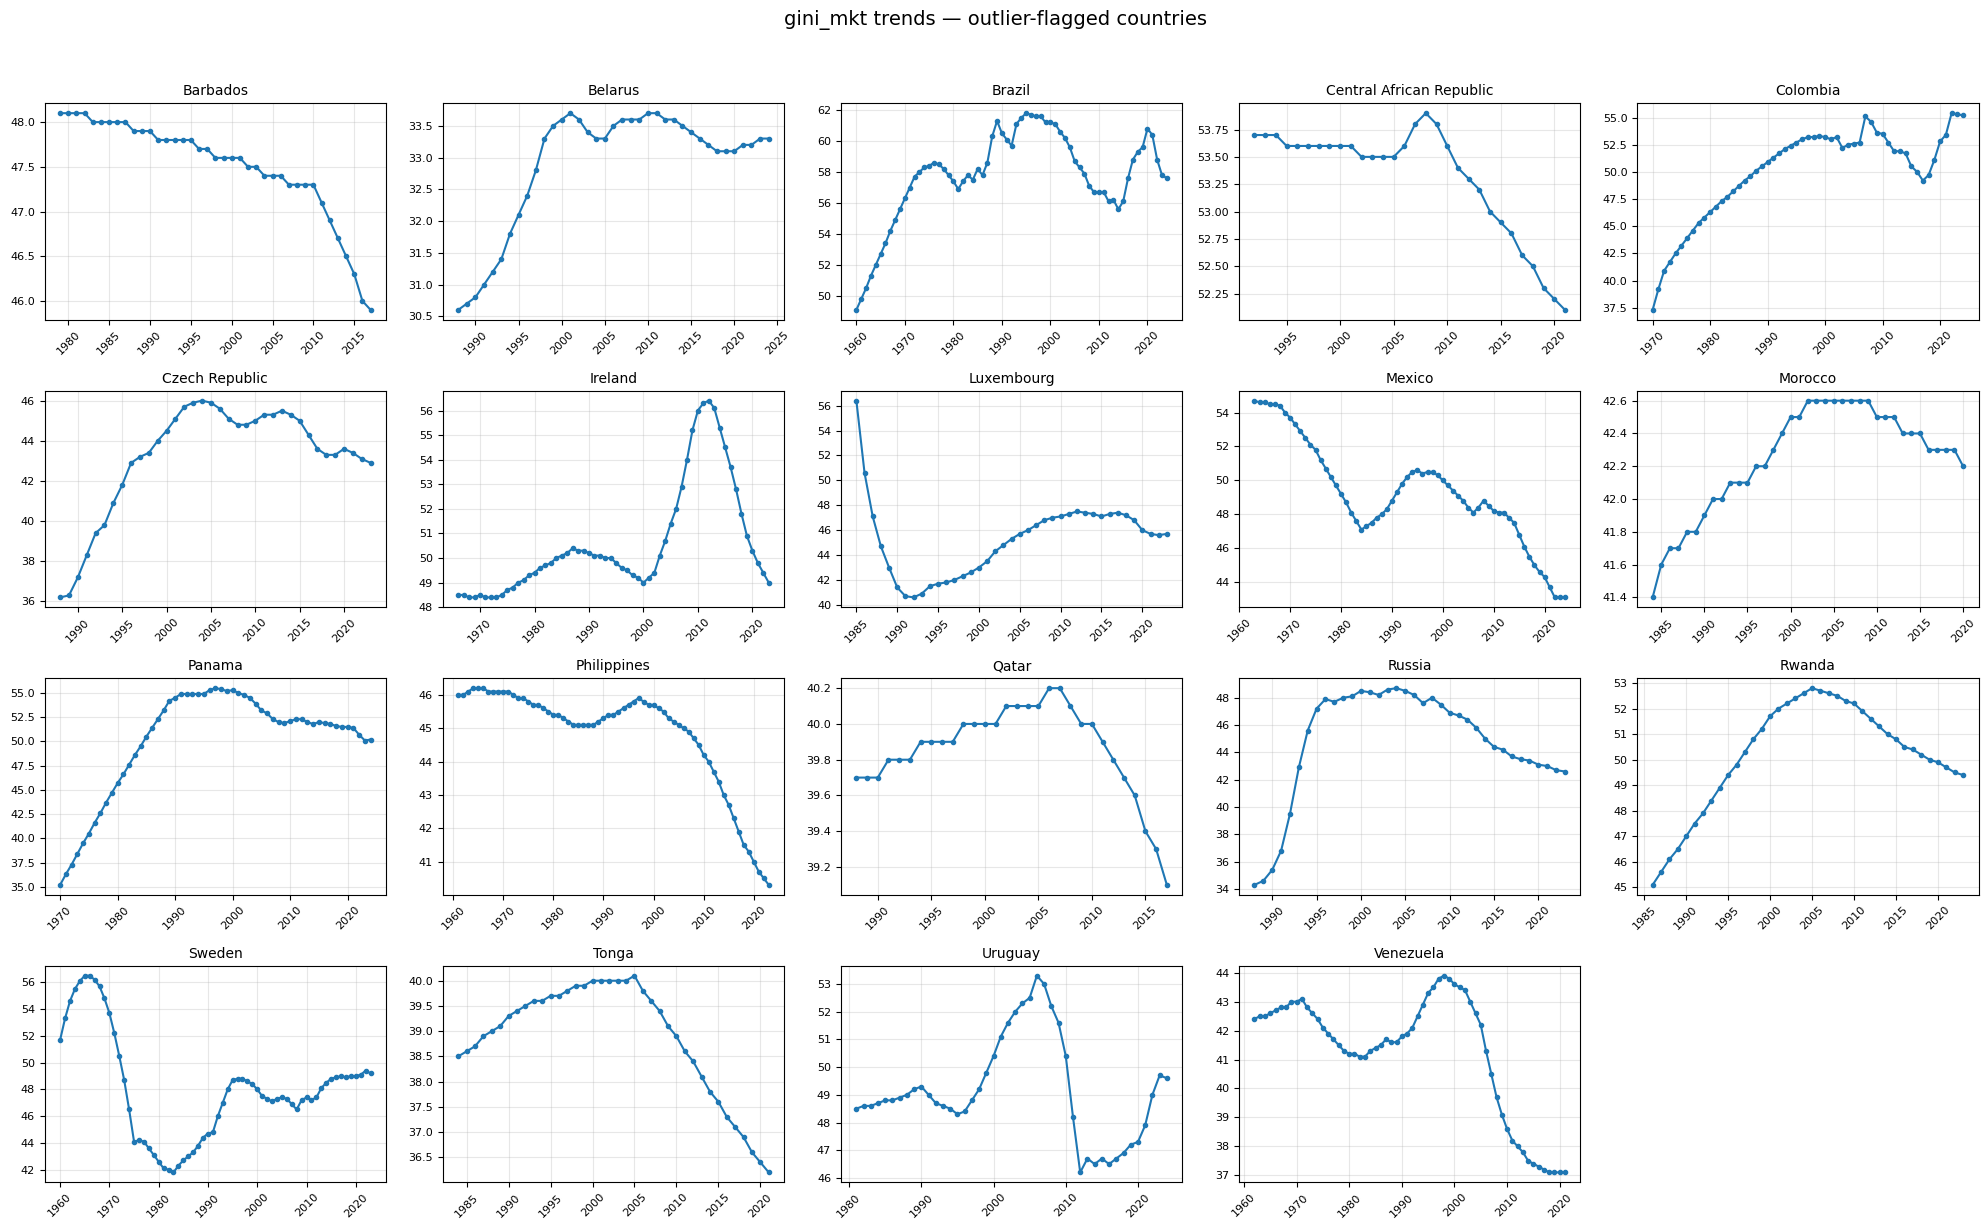

In [14]:
def plot_all_trends(df, countries, col='gini_disp', cols_per_row=4):
    countries = sorted(countries)
    n = len(countries)
    n_rows = int(np.ceil(n / cols_per_row))

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 4, n_rows * 3))
    axes = axes.flatten()  # makes indexing easy regardless of grid shape

    for i, country in enumerate(countries):
        subset = df[df['country'] == country].sort_values('year')
        axes[i].plot(subset['year'], subset[col], marker='o', markersize=3)
        axes[i].set_title(country, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].grid(alpha=0.3)

    # Hide any unused subplot slots (if grid has more cells than countries)
    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{col} trends — outlier-flagged countries', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_trends(df_filtered, gini_mkt_outliers, col='gini_mkt', cols_per_row=5)

## Outlier Review — Gini Index (SWIID)

Countries flagged by per-country IQR outlier detection (gini_disp, gini_mkt) were 
individually reviewed by plotting their full time series rather than removed automatically.

**Decision: No data points were dropped.**

Visual inspection showed that flagged values were part of coherent, gradual trend lines 
rather than erratic spikes or data entry errors — e.g. post-Soviet transition economies 
(Russia, Belarus, Czech Republic, etc.) showing a smooth structural shift in the early 
1990s, and Western European countries showing steady multi-year inequality decline in the 
1960s-80s. These reflect real, well-documented economic history rather than noise, and 
are consistent with the project's focus on divergence and structural change in inequality 
over time.

Outlier detection was therefore used as a review checkpoint, not an automatic filter.